## The Monty Hall Problem: 

* Simulate three doors, one car, and two goats.

* Simulate three players: the switcher, the conservative, and the newcomer.

* Record who wins.

* Repeat it many times.

* Which player do you want to be?

* What would happen if you had 100 doors to choose from and the presenter opens 98 or them?

* And what if you had N doors to choose from and the presenter opens M <= N-2 of them? Study how the probability of winning changes as a function of N and M .

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib as mpl
from tqdm.notebook import tqdm

Let's start with a simple run with 3 doors for N times!

In [2]:
#Setting up the initial conditions: 

N = 100 #number of trials
n_doors = 3 #number of doors
M = 1 #numer of doors opened by the host

doors = np.zeros(n_doors)
doors[0] = 1 #The winning door

#Let's keep track of the wins
sum1 = 0
sum2 = 0
sum3 = 0

#Let's start the game!
for i in tqdm(range(N)):
    door1 = random.choice(range(len(doors)))
    if door1 == 0:
        sum1 += 1
        
    pres_doors = []
    while len(pres_doors) < (M):
        new_door = random.choice(range(len(doors)))
        if (new_door != 0) and (new_door not in pres_doors) and (new_door != door1):
            pres_doors.append(new_door)

    door2 = random.choice(range(len(doors)))
    while (door2 == door1) or (door2 in pres_doors):
        door2 = random.choice(range(len(doors)))
    if door2 == 0:
        sum2 += 1

    door3 = random.choice(range(len(doors)))
    while door3 in pres_doors:
            door3 = random.choice(range(len(doors)))
    if door3 == 0:
            sum3 += 1

print('Game played', N, 'times.')
print('The conservative player won', sum1, 'times.')
print('The switcher won', sum2, 'times.')
print('The random player won', sum3, 'times.')

  0%|          | 0/100 [00:00<?, ?it/s]

Game played 100 times.
The conservative player won 32 times.
The switcher won 68 times.
The random player won 61 times.


In [3]:
#Let's compute the probability of winning of each player:
Prob1 = (sum1/N)*100
Prob2 = (sum2/N)*100
Prob3 = (sum3/N)*100

print('Probability of winning of the conervative player:', Prob1, '%')
print('Probability of winning of the switcher:', Prob2, '%')
print('Probability of winning of the random player:', Prob3, '%')

Probability of winning of the conervative player: 32.0 %
Probability of winning of the switcher: 68.0 %
Probability of winning of the random player: 61.0 %


Clearly, the player who switches doors is the one with a higher chance of winning, as expected!
.\
If we keep increasing N, we expect to have such player with a close to 70% probability of winning, 
almost 50% for the new commer and probability staying below 50% for the conservative player. 
Let's check!

In [4]:
#Keeping the same number of doors, let's see how the prob goes with N:
N = 1000 #New number of trials

doors = np.zeros(n_doors)
doors[0] = 1 

sum1_N = np.zeros(N)
sum2_N = np.zeros(N)
sum3_N = np.zeros(N)

current_wins1 = 0
current_wins2 = 0
current_wins3 = 0

for k in tqdm(range(N)):

    door1 = random.choice(range(n_doors))
    if door1 == 0:
        current_wins1 += 1

    sum1_N[k] = current_wins1 

    pres_doors = []
    while len(pres_doors) < M:
        new_door = random.choice(range(n_doors))
        if (new_door != 0) and (new_door not in pres_doors) and (new_door != door1):
            pres_doors.append(new_door)

    door2 = random.choice(range(n_doors))
    while (door2 == door1) or (door2 in pres_doors):
        door2 = random.choice(range(n_doors))  
    if door2 == 0:
        current_wins2 += 1
    sum2_N[k] = current_wins2

    door3 = random.choice(range(n_doors))
    while door3 in pres_doors:
        door3 = random.choice(range(n_doors))
    if door3 == 0:
        current_wins3 += 1
    sum3_N[k] = current_wins3

  0%|          | 0/1000 [00:00<?, ?it/s]

Text(0.5, 1.0, 'Probability of winning increasing $N_{trials}$')

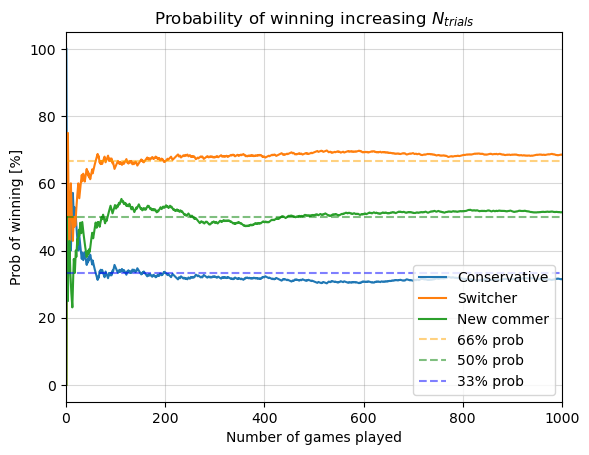

In [11]:
#Let's check the results: 
trials = np.arange(1, N+1)

plt.plot(trials, (sum1_N/trials)*100, label = 'Conservative')
plt.plot(trials, (sum2_N/trials)*100, label = 'Switcher')
plt.plot(trials, (sum3_N/trials)*100, label = 'New commer')
plt.axhline(66.66, color='orange', linestyle='--', alpha=0.5, label='66% prob')
plt.axhline(50, 0, color='green', linestyle='--', alpha =0.5, label='50% prob')
plt.axhline(33.33, color='blue', linestyle='--', alpha=0.5, label='33% prob')
plt.legend(loc = 'lower right')
plt.grid(c = 'gray', alpha = 0.3)
plt.ylabel('Prob of winning [%]')
plt.xlabel('Number of games played')
plt.xlim(0,N)
plt.title(r'Probability of winning increasing $N_{trials}$')

### Let's change the number of doors!
The number of doors opend by the host each time is still $N_{doors} - 2$ 

In [12]:
N = 100 #number of trials
n_doors = 500 #max number of doors

sum1_d = np.zeros(n_doors - 2)
sum2_d = np.zeros(n_doors - 2)
sum3_d = np.zeros(n_doors - 2)

for k in tqdm(range(3, n_doors + 1)):
    M = k - 2 
    all_doors_indices = set(range(k))
    winning_door = 0
    
    for i in range(N):
        door1 = random.choice(range(k))
        
        if door1 == winning_door:
            sum1_d[k-3] += 1
        
        forbidden = {winning_door, door1}
        available_to_open = list(all_doors_indices - forbidden)
        pres_doors = set(random.sample(available_to_open, M))
    
        closed_doors = list(all_doors_indices - pres_doors)
        switch_options = [d for d in closed_doors if d != door1]
        door2 = switch_options[0]
        if door2 == winning_door:
            sum2_d[k-3] += 1
            
        door3 = random.choice(closed_doors)
        if door3 == winning_door:
            sum3_d[k-3] += 1

  0%|          | 0/498 [00:00<?, ?it/s]

Text(0.5, 1.0, 'Increasing $N_{doors}$')

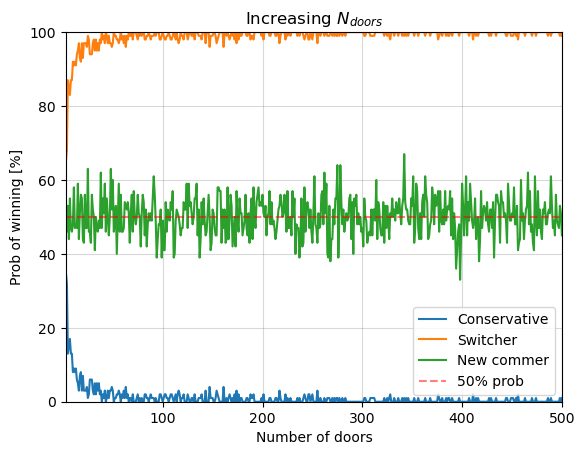

In [17]:
num_d = np.arange(3, n_doors+1)

plt.plot(num_d, (sum1_d/N)*100, label = 'Conservative')
plt.plot(num_d, (sum2_d/N)*100, label = 'Switcher')
plt.plot(num_d, (sum3_d/N)*100, label = 'New commer')
plt.axhline(50, color='r', linestyle='--', alpha=0.5, label='50% prob')
plt.legend(loc = 'lower right')
plt.grid(c = 'gray', alpha = 0.3)
plt.ylabel('Prob of winning [%]')
plt.ylim(0,100)
plt.xlabel('Number of doors')
plt.xlim(3, n_doors)
plt.title(r'Increasing $N_{doors}$')

The more are the doors, the harder it is for the conservative player to win!

### Let's change the numer of doors opened by the host!
Fixing $N_{doors} = 100$, how does the probability of winning change if the host opens less and less doors ? 

In [18]:
N = 200        #number of trials
n_doors = 100  #number of doors
M = n_doors - 2 #max numer of doors opened by the host

doors = np.zeros(n_doors)
doors[0] = 1 #winning door

sum1_M = np.zeros(M+1)
sum2_M = np.zeros(M+1)
sum3_M = np.zeros(M+1)

all_doors_indices = set(range(n_doors))

for k in tqdm(range(M+1)):

    #Let's start the game!
    for i in range(N):

        door1 = random.choice(range(n_doors))
        if door1 == 0:
            sum1_M[k] += 1

        forbidden_doors = {0, door1}
        available_to_open = list(all_doors_indices - forbidden_doors)
        pres_doors = random.sample(available_to_open, k)
        closed_doors = list(all_doors_indices - set(pres_doors))
    
        switch_options = [d for d in closed_doors if d != door1]
        door2 = random.choice(switch_options)
        if door2 == 0:
            sum2_M[k] += 1

        door3 = random.choice(closed_doors)
        if door3 == 0:
            sum3_M[k] += 1

  0%|          | 0/99 [00:00<?, ?it/s]

Text(0.5, 1.0, 'Opening less doors [$N_{doors}$ = 100]:')

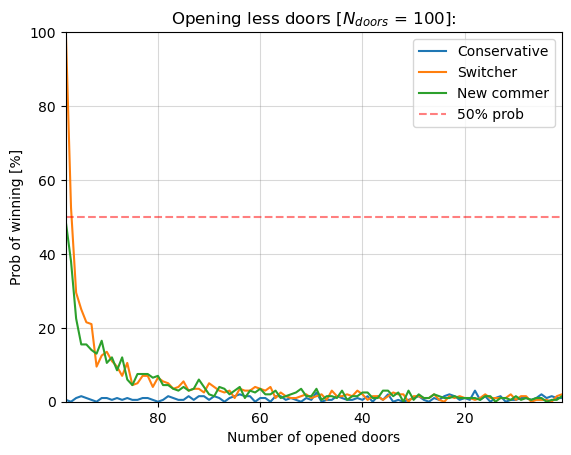

In [20]:
opened = np.arange(M+1)

plt.plot(opened, (sum1_M/N)*100, label = 'Conservative')
plt.plot(opened, (sum2_M/N)*100, label = 'Switcher')
plt.plot(opened, (sum3_M/N)*100, label = 'New commer')
plt.axhline(50, color='r', linestyle='--',alpha =0.5, label='50% prob')
plt.legend(loc = 'upper right')
plt.grid(c = 'gray', alpha = 0.3)
plt.ylabel('Prob of winning [%]')
plt.ylim(0,100)
plt.xlabel('Number of opened doors')
plt.xlim(98, 1)
plt.title(r'Opening less doors [$N_{doors}$ = 100]:' )

The less doors are opened the harder it is to win the game for any player! 